### Importing Libraries

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

%pip install statsmodels
from statsmodels.tsa.statespace.sarimax import SARIMAX

Note: you may need to restart the kernel to use updated packages.


In [7]:
import warnings
warnings.filterwarnings("ignore")

### Load libraries

In [8]:
df = pd.read_csv("Walmart.csv")

In [9]:
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


### Time Features

In [10]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [11]:
df['Date'].head()

0   2010-02-05
1   2010-02-12
2   2010-02-19
3   2010-02-26
4   2010-03-05
Name: Date, dtype: datetime64[ns]

In [12]:
df['year'] = df['Date'].dt.year

In [13]:
df['month'] = df['Date'].dt.month

In [14]:
df['week'] = df['Date'].dt.isocalendar().week

In [15]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,week
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9


## EDA

In [16]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,week
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
 8   year          6435 non-null   int32         
 9   month         6435 non-null   int32         
 10  week          6435 non-null   UInt32        
dtypes: UInt32(1), datetime64[ns](1), float64(5), int32(2), int64(2)
memory usage: 484.0 KB


In [18]:
df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,week
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.0
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151,2010.965035,6.447552,25.818182
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000,2010.000000,1.000000,1.0
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000,2010.000000,4.000000,14.0
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000,2011.000000,6.000000,26.0
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000,2012.000000,9.000000,38.0
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000,2012.000000,12.000000,52.0
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885,0.797019,3.238308,14.129201


### Missing Values

In [19]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
year            0
month           0
week            0
dtype: int64

### Sales Distribution

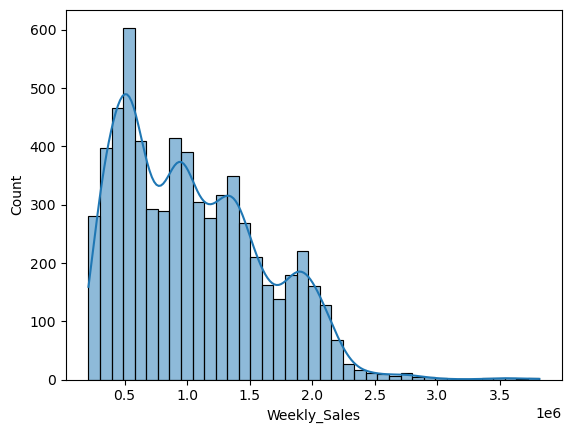

In [20]:
sns.histplot(df['Weekly_Sales'], kde=True)
plt.show()

### Sales Trend over Time

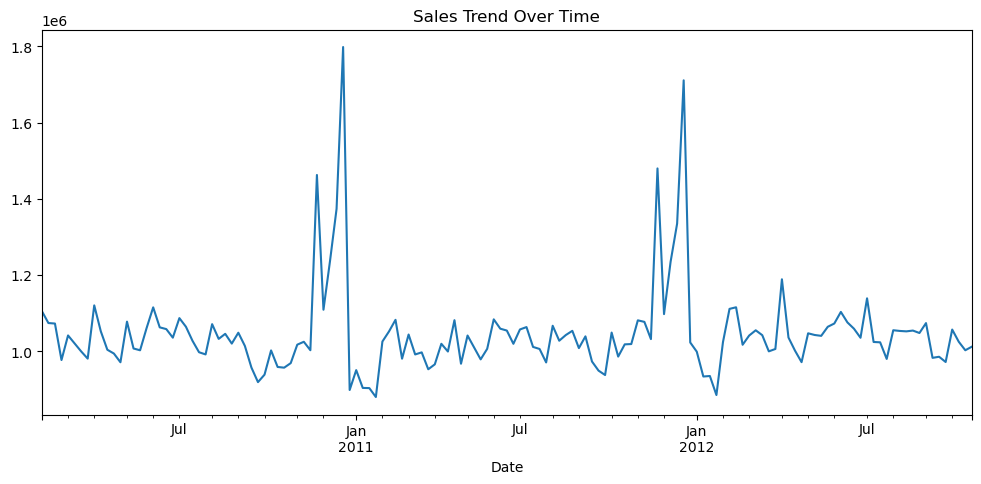

In [21]:
df.groupby('Date')['Weekly_Sales'].mean().plot(figsize=(12,5))
plt.title("Sales Trend Over Time")
plt.show()

### Holiday Impact

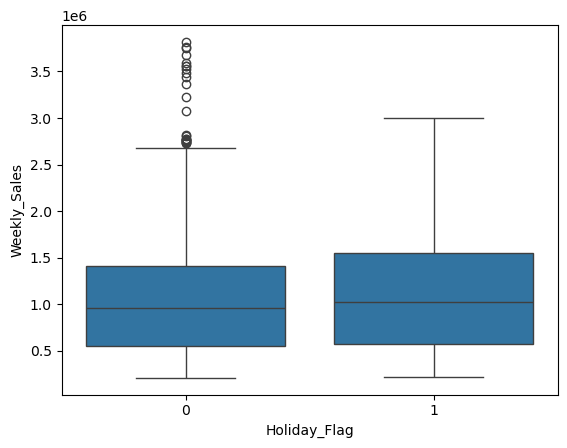

In [22]:
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df)
plt.show()

### Store-wise Performance

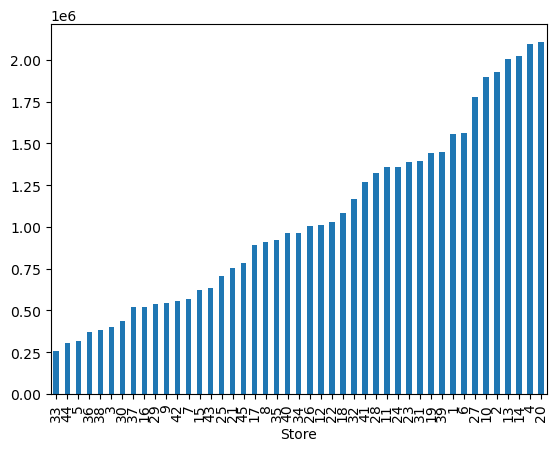

In [23]:
df.groupby('Store')['Weekly_Sales'].mean().sort_values().plot(kind='bar')
plt.show()

### Correlation Analysis

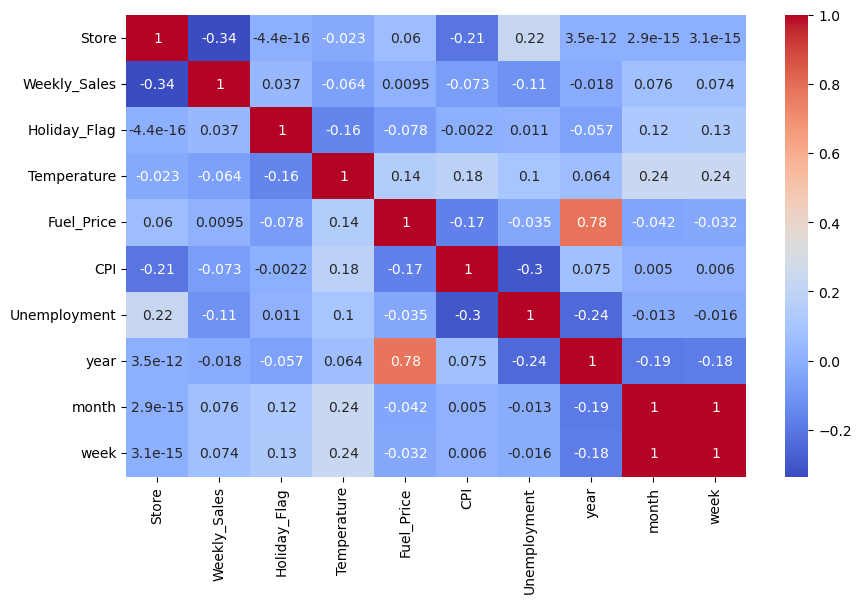

In [24]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

### Temperature vs Sales

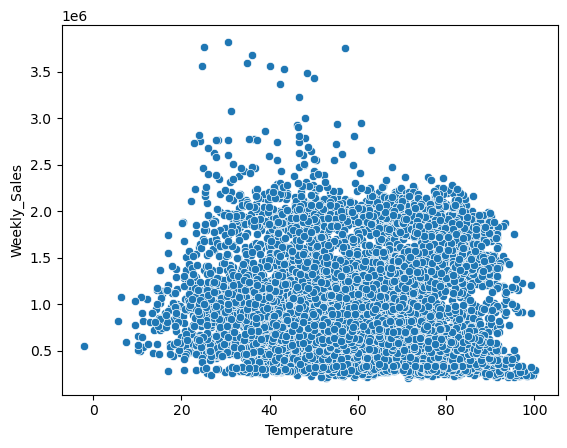

In [25]:
sns.scatterplot(x='Temperature', y='Weekly_Sales', data=df)
plt.show()

### Seasonality Check

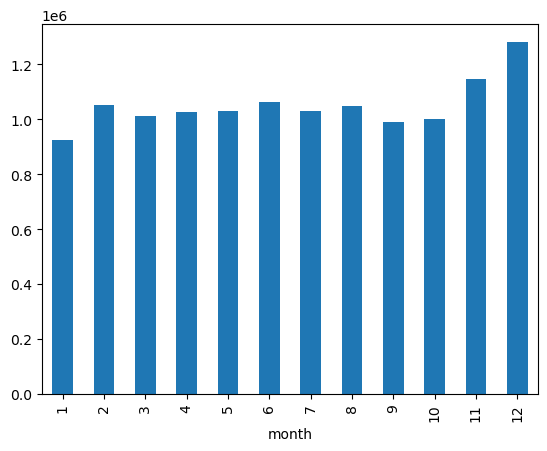

In [26]:
df.groupby('month')['Weekly_Sales'].mean().plot(kind='bar')
plt.show()

## Feature Engineering

### Lag Features

In [27]:
df['lag_1'] = df.groupby('Store')['Weekly_Sales'].shift(1)

In [28]:
df['lag_2'] = df.groupby('Store')['Weekly_Sales'].shift(2)

In [29]:
df['lag_4'] = df.groupby('Store')['Weekly_Sales'].shift(4)


In [30]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,week,lag_1,lag_2,lag_4
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,NaN,NaN,NaN
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6,1643690.90,NaN,NaN
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7,1641957.44,1643690.90,NaN
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8,1611968.17,1641957.44,NaN
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,1409727.59,1611968.17,1643690.9


### Rolling Features

In [31]:
df['rolling_mean_4'] = df.groupby('Store')['Weekly_Sales'].shift(1).rolling(4).mean()

In [32]:
df['rolling_std_4'] = df.groupby('Store')['Weekly_Sales'].shift(1).rolling(4).std()

In [33]:
df.isna().sum()

Store               0
Date                0
Weekly_Sales        0
Holiday_Flag        0
Temperature         0
Fuel_Price          0
CPI                 0
Unemployment        0
year                0
month               0
week                0
lag_1              45
lag_2              90
lag_4             180
rolling_mean_4    180
rolling_std_4     180
dtype: int64

In [34]:
df.dropna(inplace=True)

In [35]:
df.isna().sum()

Store             0
Date              0
Weekly_Sales      0
Holiday_Flag      0
Temperature       0
Fuel_Price        0
CPI               0
Unemployment      0
year              0
month             0
week              0
lag_1             0
lag_2             0
lag_4             0
rolling_mean_4    0
rolling_std_4     0
dtype: int64

## Train-Test Split (Time-Based)

In [36]:
df['year'].unique()

array([2010, 2011, 2012], dtype=int32)

In [37]:
train = df[df['Date'] < '2012-01-01']

In [38]:
test = df[df['Date'] >= '2012-01-01']

In [39]:
train.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,week,lag_1,lag_2,lag_4,rolling_mean_4,rolling_std_4
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,1409727.59,1611968.17,1643690.90,1.576836e+06,112353.415114
5,1,2010-03-12,1439541.59,0,57.79,2.667,211.380643,8.106,2010,3,10,1554806.68,1409727.59,1641957.44,1.554615e+06,103135.002548
6,1,2010-03-19,1472515.79,0,54.58,2.720,211.215635,8.106,2010,3,11,1439541.59,1554806.68,1611968.17,1.504011e+06,95360.050839
7,1,2010-03-26,1404429.92,0,51.45,2.732,211.018042,8.106,2010,3,12,1472515.79,1439541.59,1409727.59,1.469148e+06,62599.457150
8,1,2010-04-02,1594968.28,0,62.27,2.719,210.820450,7.808,2010,4,13,1404429.92,1472515.79,1554806.68,1.467823e+06,64308.381016


In [40]:
test.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,week,lag_1,lag_2,lag_4,rolling_mean_4,rolling_std_4
100,1,2012-01-06,1550369.92,0,49.01,3.157,219.714258,7.348,2012,1,1,1497462.72,2270188.99,1799682.38,1.862128e+06,318201.636955
101,1,2012-01-13,1459601.17,0,48.53,3.261,219.892526,7.348,2012,1,2,1550369.92,1497462.72,1881176.67,1.799800e+06,356609.571763
102,1,2012-01-20,1394393.84,0,54.11,3.268,219.985689,7.348,2012,1,3,1459601.17,1550369.92,2270188.99,1.694406e+06,385656.326990
103,1,2012-01-27,1319325.59,0,54.26,3.290,220.078852,7.348,2012,1,4,1394393.84,1459601.17,1497462.72,1.475457e+06,65622.253720
104,1,2012-02-03,1636339.65,0,56.55,3.360,220.172015,7.348,2012,2,5,1319325.59,1394393.84,1550369.92,1.430923e+06,98112.801714


### Regression Models

In [41]:
features = ['Store','Holiday_Flag','Temperature','Fuel_Price',
            'CPI','Unemployment','year','month','week',
            'lag_1','lag_2','lag_4','rolling_mean_4','rolling_std_4']

### Splitting for regression models

In [42]:
X_train = train[features]

In [43]:
y_train = train['Weekly_Sales']

In [44]:
X_test = test[features]

In [45]:
y_test = test['Weekly_Sales']

### Auto ML using Regresssion Models

In [46]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

### Define Models

In [47]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "XGBoost": XGBRegressor(random_state=42)
}

### Loop through models

In [48]:
results = []
for name, model in models.items():
    try:
        # Train
        model.fit(X_train, y_train)
        
        # Predict
        y_pred = model.predict(X_test)
        
        # Metrics
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        
        results.append({
            "Model": name,
            "MAE": round(mae, 2),
            "RMSE": round(rmse, 2),
            "R2 Score": round(r2, 4)
        })
        
    except Exception as e:
        print(f"{name} failed: {e}")

In [49]:
results_df = pd.DataFrame(results)

In [50]:
results_df = results_df.sort_values(by="RMSE")

In [51]:
print(results_df)

               Model        MAE       RMSE  R2 Score
8            XGBoost   48470.57   71068.37    0.9825
5  Gradient Boosting   50834.85   75686.25    0.9801
4      Random Forest   55446.57   78347.19    0.9787
6                KNN   66371.64   98795.27    0.9661
1              Ridge   72025.75   99479.06    0.9656
2              Lasso   72037.94   99490.08    0.9656
0  Linear Regression   72044.73   99495.64    0.9656
3      Decision Tree   80889.35  114774.62    0.9542
7                SVR  448811.02  540945.33   -0.0166


### Hyperparameter Tuning

In [52]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

xgb = XGBRegressor(random_state=42)

param_dist = {
    'n_estimators': [200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 5, 6, 7],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

rand_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

rand_search.fit(X_train, y_train)

best_xgb = rand_search.best_estimator_

print("Best Params:", rand_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params: {'subsample': 0.8, 'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.9}


### Evaluate Tuned Model

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = best_xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 43793.48001518088
RMSE: 64607.632257463156
R2: 0.9854987884113665


In [56]:
import pickle
pickle.dump(best_xgb, open("final_model.pkl", "wb"))